# GrC Image Matting on MIAS - Data Preparation

## Section 1 - Environment, Drive mount, and dataset acquisition

Installs dependencies, mounts Google Drive, writes the shared `config.json` that
every later notebook reloads, and pulls MIAS from Kaggle. All tunable constants
(seed, patch sizes, CLAHE tiles, ROI caps, SVM grid) live in `config.json`, so
they are set once here and never hardcoded downstream.

In [ ]:
# Install and import dependencies

!pip install -q opencv-python scikit-learn scipy Pillow tqdm joblib

import os, sys, json, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')
print("Imports OK.")

Imports OK.


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
DRIVE_ROOT = "/content/drive/MyDrive/mias_grc_project"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print(f"Project root: {DRIVE_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/mias_grc_project


In [ ]:
# Shared config file to be used by both datasets
CONFIG = {
    "SEED": 42,
    "DRIVE_ROOT": DRIVE_ROOT,
    "DATASET_DIR": "/content/mias_dataset",
    "TARGET_CLASSES": ["CIRC", "SPIC", "MISC", "NORM"],
    "MASS_CLASSES": ["CIRC", "SPIC", "MISC"],
    "NORM_SAMPLE_SIZE": 50,
    "EXPECTED_TOTAL": 322,
    "CLAHE_CLIP_LIMIT": 2.0,
    "CLAHE_TILE_FINE": [8, 8],
    "CLAHE_TILE_COARSE": [16, 16],
    "ROI_MARGIN_FACTOR": 0.3,
    "ROI_MARGIN_MIN_PX": 20,
    "ROI_MAX_RADIUS": 150,
    "TRIMAP_MIN_INNER_R": 10,
    "TRIMAP_MIN_RING_WIDTH": 5,
    "LAMBDA_VAL": 5.0,
    "PATCH_SIZES": [3, 5, 7],
    "PATCH_SINGLE": 5,
    "K_CANDIDATES": [6, 8, 10],
    "HISTOGRAM_WINDOW": 7,
    "HISTOGRAM_STRIDE": 1,
    "SVM_C_VALUES": [0.1, 1, 10],
    "SVM_GAMMA_VALUES": ["scale", "auto"],
    "HYBRID_GAMMA": 0.9,
    "MAX_NODES": 2500,
    "LAMBDA_PROPAGATION": 100.0,
    "ALPHA_THRESHOLD": 0.5,
    "HD95_PERCENTILE": 95,
}

SUBDIRS = ["outputs", "preprocessed", "trimaps", "alpha_maps",
           "models", "results", "logs", "figures"]
for d in SUBDIRS:
    p = os.path.join(DRIVE_ROOT, d)
    os.makedirs(p, exist_ok=True)
    CONFIG[d.upper() + "_DIR"] = p

with open(os.path.join(DRIVE_ROOT, "config.json"), 'w') as f:
    json.dump(CONFIG, f, indent=2)

globals().update({k: v for k, v in CONFIG.items() if isinstance(k, str)})
SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("config.json written. Later notebooks load it with:")
print("  CONFIG = json.load(open(f'{DRIVE_ROOT}/config.json'))")
print(f"Seed fixed at {SEED}.")

config.json written. Later notebooks load it with:
  CONFIG = json.load(open(f'{DRIVE_ROOT}/config.json'))
Seed fixed at 42.


In [ ]:
# Download MIAS file from Kaggle
def download_mias():
    os.makedirs(DATASET_DIR, exist_ok=True)
    pgm = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith('.pgm')] \
          if os.path.isdir(DATASET_DIR) else []
    if len(pgm) >= EXPECTED_TOTAL:
        print(f"Dataset already present: {len(pgm)} PGM files. Skipping download.")
        return True

    print("Downloading MIAS from Kaggle...")
    print("Upload your kaggle.json when prompted.")
    from google.colab import files
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
    return False

need_download = not (os.path.isdir(DATASET_DIR) and
                     len([f for f in os.listdir(DATASET_DIR)
                          if f.lower().endswith('.pgm')]) >= EXPECTED_TOTAL)
if need_download:
    download_mias()

Upload your kaggle.json when prompted.


In [ ]:
# If Cell 4 said the dataset is already present, this is a no-op re-check
if need_download:
    !pip install -q kaggle
    !kaggle datasets download -d kmader/mias-mammography -p /content/mias_dataset --unzip

pgm_files = [f for f in os.listdir(DATASET_DIR)] if os.path.isdir(DATASET_DIR) else []
n_pgm = len([f for f in pgm_files if f.lower().endswith('.pgm')])
print(f"PGM files present: {n_pgm}")
if n_pgm == 0:
    print("If the Kaggle download failed, upload the MIAS archive manually and")
    print(f"extract it to {DATASET_DIR}, then re-run this cell.")

Dataset URL: https://www.kaggle.com/datasets/kmader/mias-mammography
License(s): other
100% 312M/312M [00:14<00:00, 22.4MB/s]

PGM files present: 0
If the Kaggle download failed, upload the MIAS archive manually and
extract it to /content/mias_dataset, then re-run this cell.


In [ ]:
# Locate Info.txt and the PGM folder
def find_file(root, name_part):
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if name_part.lower() in f.lower():
                return os.path.join(dirpath, f)
    return None

INFO_PATH = find_file(DATASET_DIR, "Info.txt") or find_file(DATASET_DIR, "info")
IMAGES_DIR = None
for dirpath, _, filenames in os.walk(DATASET_DIR):
    if any(f.lower().endswith('.pgm') for f in filenames):
        IMAGES_DIR = dirpath
        break

print(f"Info file  : {INFO_PATH}")
print(f"Images dir : {IMAGES_DIR}")
assert INFO_PATH and IMAGES_DIR, "Could not locate Info.txt or the PGM folder."
CONFIG['INFO_PATH'] = INFO_PATH
CONFIG['IMAGES_DIR'] = IMAGES_DIR
with open(os.path.join(DRIVE_ROOT, "config.json"), 'w') as f:
    json.dump(CONFIG, f, indent=2)

Info file  : /content/mias_dataset/Info.txt
Images dir : /content/mias_dataset/all-mias


## Section 2 - Annotation parsing and case selection

Parses `Info.txt` into a dataframe, keeps only the four target classes
(CIRC, SPIC, MISC, NORM), drops incomplete annotations, samples 50 NORM cases,
and de-duplicates the bilateral entries where one image appears twice under two
breast sides.

In [ ]:
# Parse annotations
def parse_info(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) < 3 or not p[0].lower().startswith('mdb'):
                continue
            rec = {
                'image_id': p[0].upper(),
                'tissue'  : p[1].upper(),
                'class'   : p[2].upper(),
                'severity': p[3].upper() if len(p) > 3 else None,
                'x'       : None, 'y': None, 'radius': None,
            }
            if len(p) >= 7:
                try:
                    rec['x'] = float(p[4]); rec['y'] = float(p[5]); rec['radius'] = float(p[6])
                except ValueError:
                    pass
            rows.append(rec)
    return pd.DataFrame(rows)

info_df = parse_info(INFO_PATH)
print(f"Parsed {len(info_df)} annotation rows.")
print(f"Unique images: {info_df['image_id'].nunique()}")
print("\nClass counts:")
print(info_df['class'].value_counts().to_string())

Parsed 330 annotation rows.
Unique images: 322

Class counts:
class
NORM    207
CALC     30
CIRC     25
SPIC     19
ARCH     19
MISC     15
ASYM     15


In [ ]:
# Filter, drop invalid, sample NORM, dedupe
df = info_df[info_df['class'].isin(TARGET_CLASSES)].copy()
print(f"After class filter: {len(df)} rows")

# Drop mass cases with missing or zero radius
mass = df[df['class'] != 'NORM']
bad = mass[(mass['radius'].isna()) | (mass['radius'] <= 0)]
if len(bad):
    print(f"Dropping {len(bad)} mass rows with missing/zero radius: "
          f"{bad['image_id'].tolist()}")
df = df[~df.index.isin(bad.index)]

# Deduplicate bilateral cases (same image_id listed twice)
dupes = df[df.duplicated('image_id', keep=False)]['image_id'].unique()
if len(dupes):
    print(f"Deduplicating {len(dupes)} bilateral cases: {list(dupes)}")
    # keep the row with the larger radius (the more prominent finding)
    df = (df.sort_values('radius', ascending=False)
            .drop_duplicates('image_id', keep='first'))

norm = df[df['class'] == 'NORM']
mass = df[df['class'] != 'NORM']
print(f"NORM available: {len(norm)}, sampling {NORM_SAMPLE_SIZE}")
norm_s = norm.sample(n=min(NORM_SAMPLE_SIZE, len(norm)), random_state=SEED)

final_df = pd.concat([mass, norm_s]).sort_values('image_id').reset_index(drop=True)
print(f"\nFinal working set: {len(final_df)} cases")
print(final_df['class'].value_counts().to_string())

After class filter: 266 rows
Dropping 1 mass rows with missing/zero radius: ['MDB059']
Deduplicating 3 bilateral cases: ['MDB005', 'MDB132', 'MDB144']
NORM available: 207, sampling 50

Final working set: 105 cases
class
NORM    50
CIRC    22
SPIC    19
MISC    14


## Section 3 - Image loading and validation

Loads all 105 PGM images and validates shape, dtype and intensity range before
any preprocessing runs. Filename case is normalised here (`mdb001.pgm` against the
`MDB001` used in the annotation file).

In [ ]:
# Load and validate PGM images
def load_pgm(image_id):
    for ext in ['.pgm', '.PGM']:
        p = os.path.join(IMAGES_DIR, image_id.lower() + ext)
        if os.path.exists(p):
            return cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        p = os.path.join(IMAGES_DIR, image_id.upper() + ext)
        if os.path.exists(p):
            return cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    return None

loaded_images = {}
FAILED = []
for _, row in tqdm(final_df.iterrows(), total=len(final_df), desc="loading"):
    iid = row['image_id']
    img = load_pgm(iid)
    if img is None:
        FAILED.append({'image_id': iid, 'reason': 'file not found'}); continue
    if img.shape != (1024, 1024):
        FAILED.append({'image_id': iid, 'reason': f'shape {img.shape}'}); continue
    if img.mean() < 1.0:
        FAILED.append({'image_id': iid, 'reason': 'near-black image'}); continue
    loaded_images[iid] = img.astype(np.uint8)

final_df_loaded = final_df[final_df['image_id'].isin(loaded_images)].reset_index(drop=True)
print(f"\nLoaded {len(loaded_images)} images, {len(FAILED)} failed.")
if FAILED:
    print(FAILED)

final_df_loaded.to_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"), index=False)
np.savez_compressed(os.path.join(RESULTS_DIR, "loaded_images.npz"), **loaded_images)
with open(os.path.join(LOGS_DIR, "failed_cases_section3.json"), 'w') as f:
    json.dump(FAILED, f, indent=2)
print("Saved final_df_loaded.csv and loaded_images.npz")

loading: 100%|██████████| 105/105 [00:00<00:00, 593.68it/s]



Loaded 105 images, 0 failed.
Saved final_df_loaded.csv and loaded_images.npz


## Section 4 - Preprocessing: multi-scale CLAHE, ROI extraction, trimaps

Implements **Modification 1 (multi-scale CLAHE)** - the 8×8 and 16×16 tile
configurations are computed and combined — then crops a square ROI around the
annotated centroid and builds the three-region trimap (confident foreground disc,
unknown ring, background) from the same capped radius.

The radius is capped at 150 px so that a small number of outlier annotations do
not produce ROIs large enough to dominate the later batch stages. The cap is
applied identically to the ROI and the trimap so the two never disagree.

In [ ]:
# Preprocessing functions
def remove_background(img):
    """Otsu threshold, keep the largest connected component (the breast)."""
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(th, 8)
    if n <= 1:
        return img, np.ones_like(img, bool)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (lab == largest)
    return (img * mask).astype(np.uint8), mask

def mask_pectoral(img, breast_mask):
    """Approximate corner-triangle removal of the pectoral muscle."""
    h, w = img.shape
    left_sum  = breast_mask[:, :w//2].sum()
    right_sum = breast_mask[:, w//2:].sum()
    out = img.copy()
    tri_h, tri_w = int(h * 0.35), int(w * 0.30)
    if left_sum >= right_sum:
        pts = np.array([[0, 0], [tri_w, 0], [0, tri_h]])
    else:
        pts = np.array([[w, 0], [w - tri_w, 0], [w, tri_h]])
    cv2.fillPoly(out, [pts], 0)
    return out

def multiscale_clahe(img):
    """Modification 1: CLAHE at two tile sizes, averaged."""
    f = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                        tileGridSize=tuple(CLAHE_TILE_FINE)).apply(img)
    c = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                        tileGridSize=tuple(CLAHE_TILE_COARSE)).apply(img)
    return ((f.astype(np.float32) + c.astype(np.float32)) / 2.0).astype(np.uint8)

def normalize01(img):
    a = img.astype(np.float32)
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo) if hi > lo else np.zeros_like(a)

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [ ]:
# ROI and trimap
def extract_roi(norm_img, row):
    """Square ROI centred on the annotation. Radius capped at ROI_MAX_RADIUS."""
    h, w = norm_img.shape
    cx, cy, r = row['x'], row['y'], row['radius']
    if pd.isna(cx) or pd.isna(cy) or pd.isna(r):
        return None, None, None

    # MIAS y is measured from the bottom edge
    cy_img = h - cy
    r_eff = min(float(r), ROI_MAX_RADIUS)
    capped = float(r) > ROI_MAX_RADIUS

    margin  = max(ROI_MARGIN_MIN_PX, int(r_eff * ROI_MARGIN_FACTOR))
    total_r = int(r_eff + margin)

    x1, x2 = int(cx - total_r), int(cx + total_r)
    y1, y2 = int(cy_img - total_r), int(cy_img + total_r)
    x1c, y1c = max(0, x1), max(0, y1)
    x2c, y2c = min(w, x2), min(h, y2)

    roi = norm_img[y1c:y2c, x1c:x2c]
    if roi.size == 0:
        return None, None, None

    side = 2 * total_r
    if roi.shape != (side, side):
        padded = np.zeros((side, side), np.float32)
        padded[y1c-y1:y1c-y1+roi.shape[0], x1c-x1:x1c-x1+roi.shape[1]] = roi
        roi = padded
    return roi.astype(np.float32), total_r, capped

def make_trimap(roi_shape, radius, total_r):
    """255 definite mass, 0 definite background, 128 unknown."""
    h, w = roi_shape
    scale = (w / 2.0) / float(total_r)
    r_px  = float(radius) * scale
    inner = max(TRIMAP_MIN_INNER_R, r_px * 0.5)
    outer = max(inner + TRIMAP_MIN_RING_WIDTH, r_px * 1.3)

    yy, xx = np.ogrid[:h, :w]
    d = np.sqrt((xx - w/2.0)**2 + (yy - h/2.0)**2)
    tm = np.full((h, w), 128, np.uint8)
    tm[d <= inner] = 255
    tm[d >= outer] = 0
    return tm

print("ROI and trimap functions defined.")

ROI and trimap functions defined.


In [ ]:
# Run preprocessing on every case
preprocessed_results = {}
meta_rows = []

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="preprocessing"):
    iid, cls = row['image_id'], row['class']
    img = loaded_images[iid]

    bg_removed, breast_mask = remove_background(img)
    pect = mask_pectoral(bg_removed, breast_mask)
    enh  = multiscale_clahe(pect)
    norm = normalize01(enh)

    if cls == 'NORM':
        h, w = norm.shape
        s = 200
        roi = norm[h//2 - s//2:h//2 + s//2, w//2 - s//2:w//2 + s//2].astype(np.float32)
        total_r, capped, trimap = s // 2, False, None
    else:
        roi, total_r, capped = extract_roi(norm, row)
        if roi is None:
            continue
        trimap = make_trimap(roi.shape, row['radius'], total_r)

    preprocessed_results[iid] = {
        'image_id': iid, 'roi': roi, 'trimap': trimap,
        'full_image_normalized': norm.astype(np.float32),
    }
    meta_rows.append({
        'image_id': iid, 'class': cls, 'tissue': row['tissue'],
        'roi_size': roi.shape[0], 'total_r': total_r,
        'annotated_radius': row['radius'], 'radius_capped': capped,
    })

metadata_df = pd.DataFrame(meta_rows)
n_capped = int(metadata_df['radius_capped'].sum())
print(f"\nPreprocessed {len(preprocessed_results)} cases.")
print(f"ROI radius capped on {n_capped} case(s) "
      f"(cap = {ROI_MAX_RADIUS} px)")
if n_capped:
    print(metadata_df[metadata_df['radius_capped']][
        ['image_id', 'annotated_radius', 'roi_size']].to_string(index=False))
print(f"\nROI size: min {metadata_df['roi_size'].min()}, "
      f"max {metadata_df['roi_size'].max()}, "
      f"mean {metadata_df['roi_size'].mean():.0f}")

preprocessing: 100%|██████████| 105/105 [00:02<00:00, 42.07it/s]


Preprocessed 105 cases.
ROI radius capped on 2 case(s) (cap = 150 px)
image_id  annotated_radius  roi_size
  MDB001             197.0       390
  MDB148             174.0       390

ROI size: min 74, max 390, mean 174


In [ ]:
# Save output files
np.savez_compressed(os.path.join(PREPROCESSED_DIR, "rois.npz"),
                    **{k: v['roi'] for k, v in preprocessed_results.items()})
np.savez_compressed(os.path.join(PREPROCESSED_DIR, "full_normalized.npz"),
                    **{k: v['full_image_normalized'] for k, v in preprocessed_results.items()})
np.savez_compressed(os.path.join(TRIMAPS_DIR, "trimaps.npz"),
                    **{k: v['trimap'] for k, v in preprocessed_results.items()
                       if v['trimap'] is not None})
metadata_df.to_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"), index=False)
print("Saved rois.npz, full_normalized.npz, trimaps.npz, preprocessing_metadata.csv")

Saved rois.npz, full_normalized.npz, trimaps.npz, preprocessing_metadata.csv


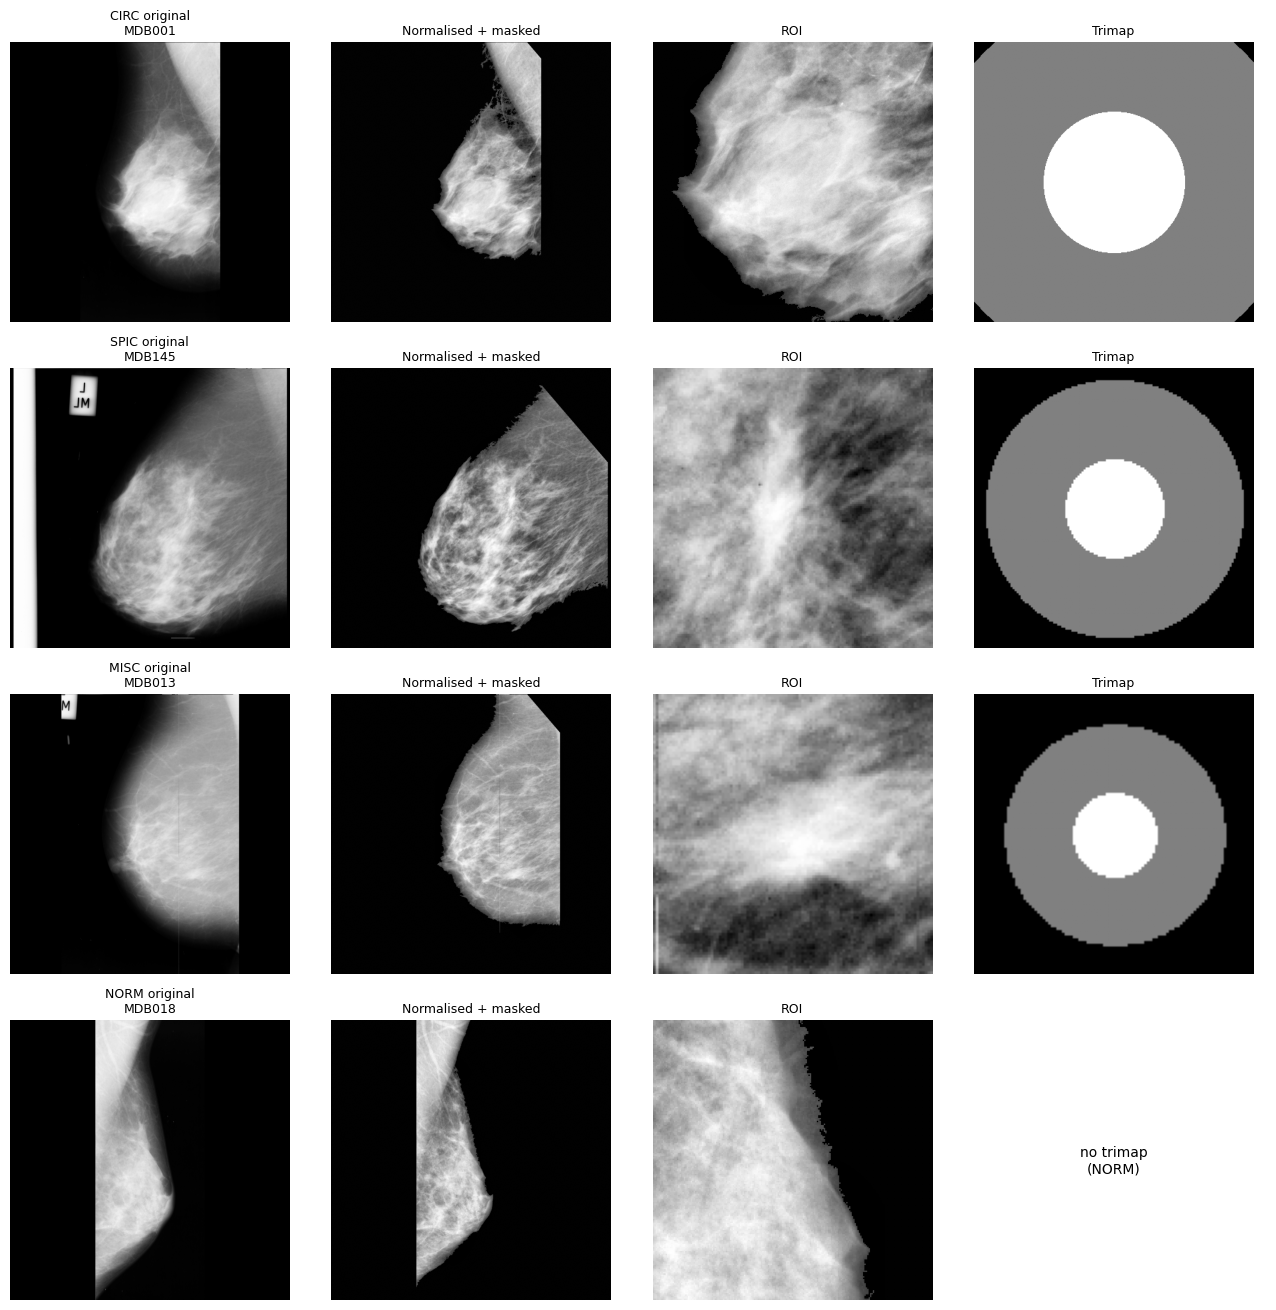

Saved section4_sample_verification.png


In [ ]:
# Image verification figure
def one_per_class(df, pool):
    out = {}
    for c in TARGET_CLASSES:
        for _, r in df[df['class'] == c].iterrows():
            if r['image_id'] in pool:
                out[c] = r['image_id']; break
    return out

picks = one_per_class(final_df_loaded, preprocessed_results)
n = len(picks)
fig, axes = plt.subplots(n, 4, figsize=(13, 3.3*n))
if n == 1: axes = axes.reshape(1, -1)
for r, (cls, iid) in enumerate(picks.items()):
    d = preprocessed_results[iid]
    axes[r,0].imshow(loaded_images[iid], cmap='gray'); axes[r,0].set_title(f"{cls} original\n{iid}", fontsize=9)
    axes[r,1].imshow(d['full_image_normalized'], cmap='gray'); axes[r,1].set_title("Normalised + masked", fontsize=9)
    axes[r,2].imshow(d['roi'], cmap='gray'); axes[r,2].set_title("ROI", fontsize=9)
    if d['trimap'] is not None:
        axes[r,3].imshow(d['trimap'], cmap='gray'); axes[r,3].set_title("Trimap", fontsize=9)
    else:
        axes[r,3].text(0.5, 0.5, "no trimap\n(NORM)", ha='center', va='center')
    for c in range(4): axes[r,c].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section4_sample_verification.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved section4_sample_verification.png")

In [ ]:
# Final notebook Verification
def verify_1to4():
    checks = {
        "config.json written"    : os.path.exists(os.path.join(DRIVE_ROOT, "config.json")),
        "final_df_loaded saved"  : os.path.exists(os.path.join(RESULTS_DIR, "final_df_loaded.csv")),
        "images loaded"          : len(loaded_images) > 0,
        "all 1024x1024"          : all(v.shape == (1024,1024) for v in loaded_images.values()),
        "preprocessing complete" : len(preprocessed_results) == len(final_df_loaded),
        "ROIs saved"             : os.path.exists(os.path.join(PREPROCESSED_DIR, "rois.npz")),
        "trimaps saved"          : os.path.exists(os.path.join(TRIMAPS_DIR, "trimaps.npz")),
        "metadata saved"         : os.path.exists(os.path.join(PREPROCESSED_DIR,
                                                  "preprocessing_metadata.csv")),
        "ROI in [0,1]"           : all(v['roi'].min() >= 0 and v['roi'].max() <= 1
                                       for v in preprocessed_results.values()),
    }
    print("=" * 52); print("NOTEBOOK 1 (SECTIONS 1-4) VERIFICATION"); print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}"); ok = ok and v
    print("=" * 52)
    print("Proceed to notebook 2." if ok else "Fix failures first.")
    return ok

verify_1to4()